# Exp7.2.4 — Global-window evaluation

Analysis-only notebook. It reads finalized summary/report CSVs from Exp7.2.4 and never loads checkpoints or per-run artifacts.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / 'scripts' / 'experiment_7_2_4_global_window_eval.py').exists():
            return candidate
    raise FileNotFoundError('Could not find writingRing repo root')

repo_root = find_repo_root()
root = repo_root / 'notebooks' / 'artifacts' / 'experiment_7_2_4_global_window_eval' / 'global_window_eval_v1'
task_only = pd.read_csv(root / 'report_table_task_only.csv')
task_reg = pd.read_csv(root / 'report_table_task_plus_reg.csv')
global_summary = pd.read_csv(root / 'global_window_probe_summary.csv')
deltas = pd.read_csv(root / 'global_vs_valid_delta_summary.csv')
tail = pd.read_csv(root / 'l2_tail_activity_summary.csv')
tail_offsets = pd.read_csv(root / 'l2_tail_offset_summary.csv')


## Task-only — valid length known

This is the original Exp7.2.3 valid-length view, collapsed across the two backbones and three seeds.


In [2]:
def valid_table(df):
    out = df[['family_label', 'native_ba_valid', 'l2_wc_valid_ba', 'l2_f250_valid_ba', 'valid_phase_gain_pp']].copy()
    for col in ['native_ba_valid', 'l2_wc_valid_ba', 'l2_f250_valid_ba']:
        out[col] = 100.0 * out[col]
    return out.rename(columns={
        'family_label': 'Family',
        'native_ba_valid': 'Native BA (%)',
        'l2_wc_valid_ba': 'L2 WC valid (%)',
        'l2_f250_valid_ba': 'L2 F250 valid (%)',
        'valid_phase_gain_pp': 'F250-WC (pp)',
    }).round(2)

valid_table(task_only)


,Family,Native BA (%),L2 WC valid (%),L2 F250 valid (%),F250-WC (pp)
0,A1 shared TSCE,49.35,58.08,58.39,0.31
1,A2 shared WC,55.20,55.95,56.57,0.62
2,F1 Fixed250 TSCE,56.49,53.29,61.10,7.80
3,F2 Fixed250 WC,57.04,50.23,57.60,7.37
4,"S1 spike WC, beta=.5",47.78,53.41,57.68,4.27
5,"S2 spike TSCE, beta=.5",31.83,39.88,41.81,1.93
6,"S3 spike WC, beta=1",38.61,45.41,52.41,7.00
7,"S4 spike TSCE, beta=1",25.16,38.86,42.28,3.41


## Task-only — full 256-step global window

Global WholeCount and Global Fixed250 do not use valid lengths. The native BA column remains the original valid-length native reference.


In [3]:
def global_table(df):
    out = df[['family_label', 'native_ba_valid', 'l2_wc_global_ba', 'l2_f250_global_ba', 'global_phase_gain_pp', 'wc_global_minus_valid_pp', 'f250_global_minus_valid_pp']].copy()
    for col in ['native_ba_valid', 'l2_wc_global_ba', 'l2_f250_global_ba']:
        out[col] = 100.0 * out[col]
    return out.rename(columns={
        'family_label': 'Family',
        'native_ba_valid': 'Native BA valid ref (%)',
        'l2_wc_global_ba': 'L2 Global WC (%)',
        'l2_f250_global_ba': 'L2 Global F250 (%)',
        'global_phase_gain_pp': 'Global F250-WC (pp)',
        'wc_global_minus_valid_pp': 'WC Global-Valid (pp)',
        'f250_global_minus_valid_pp': 'F250 Global-Valid (pp)',
    }).round(2)

global_table(task_only)


,Family,Native BA valid ref (%),L2 Global WC (%),L2 Global F250 (%),Global F250-WC (pp),WC Global-Valid (pp),F250 Global-Valid (pp)
0,A1 shared TSCE,49.35,55.49,55.16,-0.33,-2.58,-3.23
1,A2 shared WC,55.20,54.66,55.48,0.82,-1.29,-1.10
2,F1 Fixed250 TSCE,56.49,50.70,63.71,13.01,-2.59,2.62
3,F2 Fixed250 WC,57.04,52.04,57.41,5.37,1.81,-0.19
4,"S1 spike WC, beta=.5",47.78,52.97,55.43,2.47,-0.44,-2.24
5,"S2 spike TSCE, beta=.5",31.83,37.39,44.15,6.75,-2.48,2.34
6,"S3 spike WC, beta=1",38.61,45.18,52.06,6.88,-0.23,-0.35
7,"S4 spike TSCE, beta=1",25.16,36.79,45.21,8.41,-2.07,2.93


## Task + regularizer — valid length known


In [4]:
valid_table(task_reg)


,Family,Native BA (%),L2 WC valid (%),L2 F250 valid (%),F250-WC (pp)
0,A1 shared TSCE,49.94,57.65,60.29,2.64
1,A2 shared WC,53.66,55.46,57.37,1.91
2,F1 Fixed250 TSCE,58.57,52.98,58.95,5.97
3,F2 Fixed250 WC,56.83,52.23,56.49,4.26
4,"S1 spike WC, beta=.5",45.21,48.59,55.46,6.87
5,"S2 spike TSCE, beta=.5",23.14,25.75,28.02,2.27
6,"S3 spike WC, beta=1",36.10,40.66,49.16,8.49
7,"S4 spike TSCE, beta=1",22.39,28.33,28.71,0.38


## Task + regularizer — full 256-step global window


In [5]:
global_table(task_reg)


,Family,Native BA valid ref (%),L2 Global WC (%),L2 Global F250 (%),Global F250-WC (pp),WC Global-Valid (pp),F250 Global-Valid (pp)
0,A1 shared TSCE,49.94,56.16,56.22,0.05,-1.49,-4.08
1,A2 shared WC,53.66,54.83,55.51,0.68,-0.63,-1.86
2,F1 Fixed250 TSCE,58.57,52.58,59.71,7.13,-0.40,0.76
3,F2 Fixed250 WC,56.83,50.83,57.24,6.42,-1.40,0.75
4,"S1 spike WC, beta=.5",45.21,47.95,53.54,5.59,-0.64,-1.93
5,"S2 spike TSCE, beta=.5",23.14,26.53,28.88,2.35,0.78,0.85
6,"S3 spike WC, beta=1",36.10,38.87,47.07,8.20,-1.79,-2.09
7,"S4 spike TSCE, beta=1",22.39,27.13,28.86,1.73,-1.20,0.15


## Architecture-specific endpoint sensitivity

Negative values mean that replacing valid-length aggregation with the full 256-step window reduced test balanced accuracy.


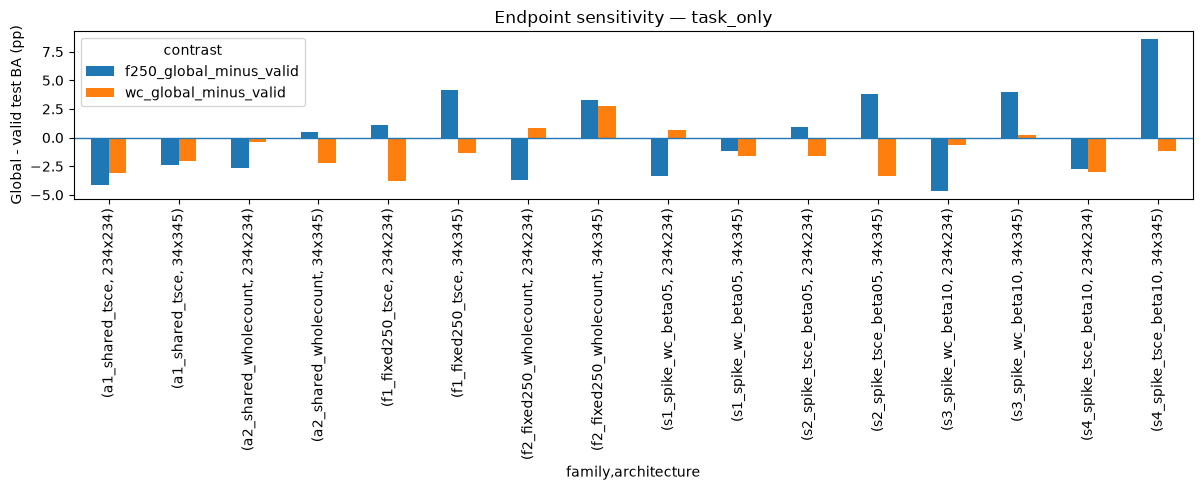

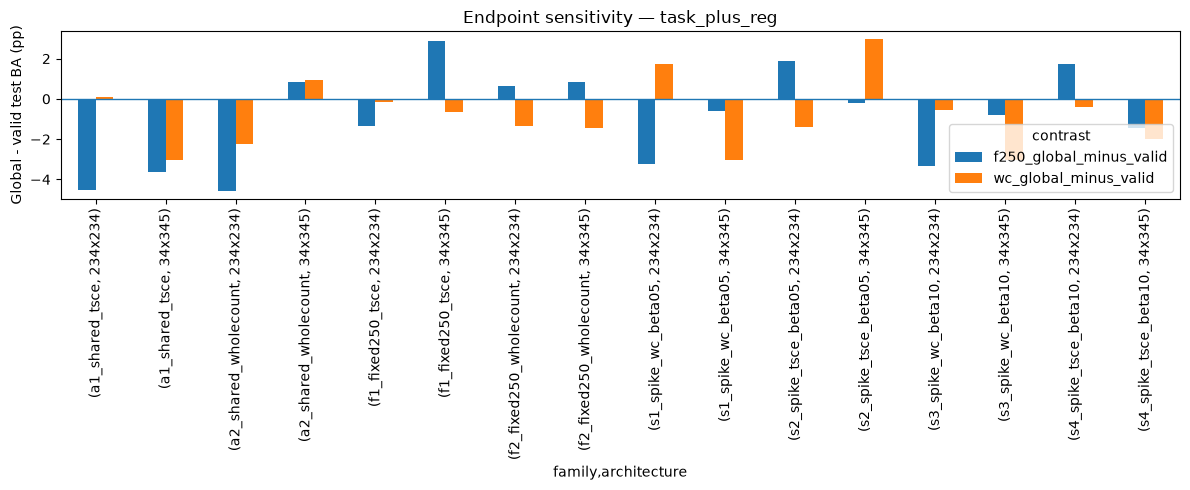

In [6]:
view = deltas[(deltas['metric'] == 'balanced_accuracy') & deltas['contrast'].isin(['wc_global_minus_valid', 'f250_global_minus_valid'])].copy()
view['delta_pp'] = 100.0 * view['delta_mean']
for regularization in ['task_only', 'task_plus_reg']:
    sub = view[view['regularization'] == regularization]
    pivot = sub.pivot_table(index=['family', 'architecture'], columns='contrast', values='delta_pp')
    ax = pivot.plot(kind='bar', figsize=(12, 5))
    ax.axhline(0, linewidth=1)
    ax.set_ylabel('Global - valid test BA (pp)')
    ax.set_title(f'Endpoint sensitivity — {regularization}')
    plt.tight_layout()
    plt.show()


## L2 post-end tail activity


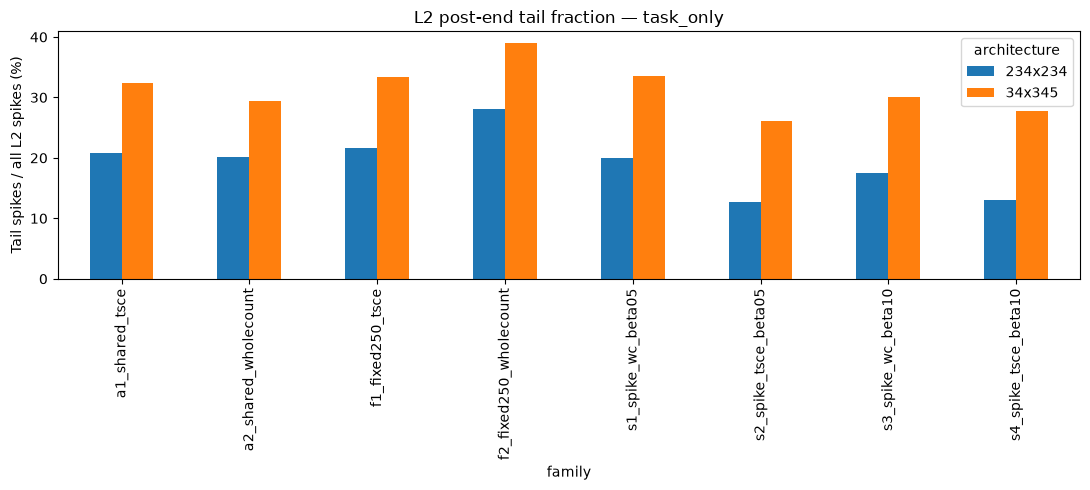

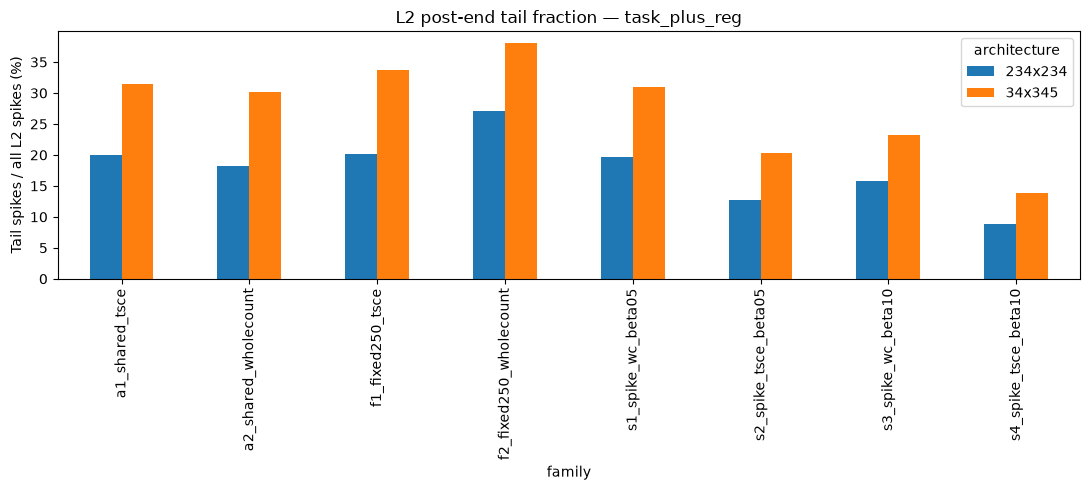

In [7]:
test_tail = tail[tail['split'] == 'test'].copy()
for regularization in ['task_only', 'task_plus_reg']:
    sub = test_tail[test_tail['regularization'] == regularization]
    pivot = sub.pivot_table(index='family', columns='architecture', values='tail_fraction_mean')
    ax = (100.0 * pivot).plot(kind='bar', figsize=(11, 5))
    ax.set_ylabel('Tail spikes / all L2 spikes (%)')
    ax.set_title(f'L2 post-end tail fraction — {regularization}')
    plt.tight_layout()
    plt.show()


## Tail decay relative to the true endpoint


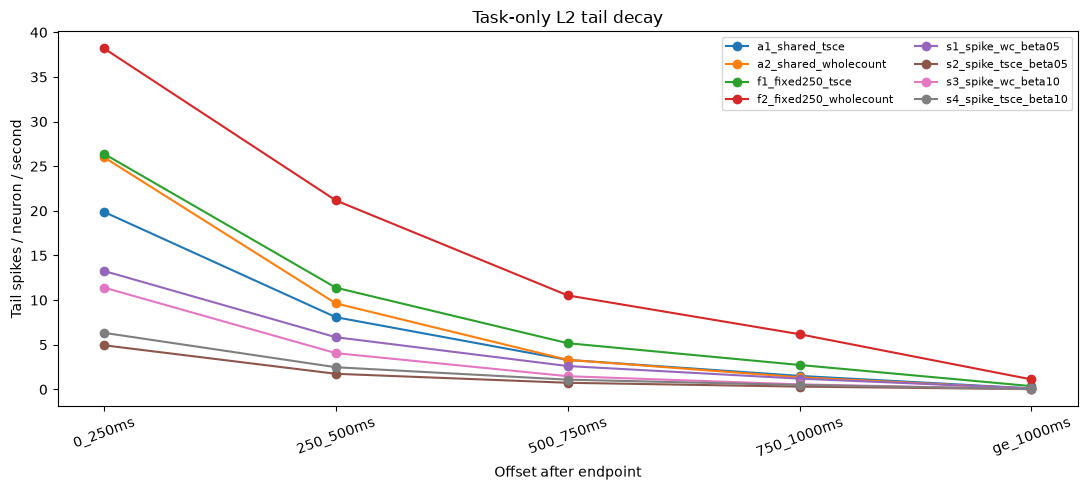

In [8]:
order = ['0_250ms', '250_500ms', '500_750ms', '750_1000ms', 'ge_1000ms']
sub = tail_offsets[(tail_offsets['split'] == 'test') & (tail_offsets['regularization'] == 'task_only')].copy()
sub['offset'] = pd.Categorical(sub['offset'], categories=order, ordered=True)
fig, ax = plt.subplots(figsize=(11, 5))
for family, group in sub.groupby('family', observed=False):
    curve = group.groupby('offset', observed=False)['spikes_per_neuron_second_mean'].mean().reindex(order)
    ax.plot(order, curve.values, marker='o', label=family)
ax.set_ylabel('Tail spikes / neuron / second')
ax.set_xlabel('Offset after endpoint')
ax.set_title('Task-only L2 tail decay')
ax.legend(ncol=2, fontsize=8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
